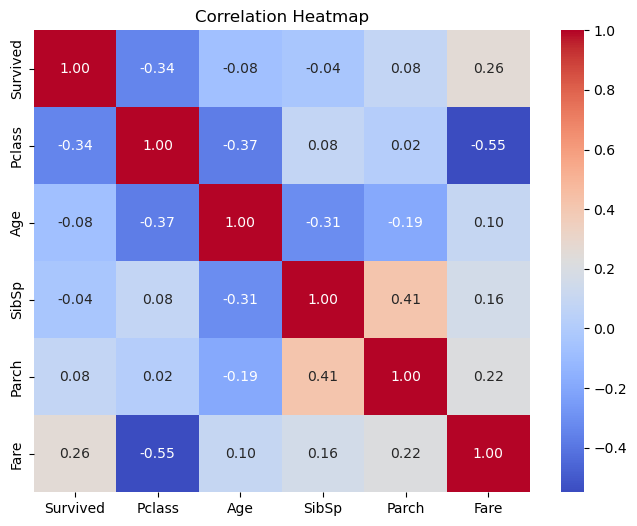

Strongest Positive Relationship:
('SibSp', 'Parch') = 0.41483769862015624

Strongest Negative Relationship:
('Pclass', 'Fare') = -0.5494996199439076


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("train.csv")

# Select numerical columns
numeric_data = data[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]

# Calculate correlation
correlation = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Remove diagonal values
corr_values = correlation.where(
    ~np.eye(correlation.shape[0], dtype=bool)
)

# Find strongest positive and negative relationships
strongest_positive = corr_values.stack().idxmax()
positive_value = corr_values.stack().max()

strongest_negative = corr_values.stack().idxmin()
negative_value = corr_values.stack().min()

print("Strongest Positive Relationship:")
print(strongest_positive, "=", positive_value)

print("\nStrongest Negative Relationship:")
print(strongest_negative, "=", negative_value)


Survival Rate by Sex:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


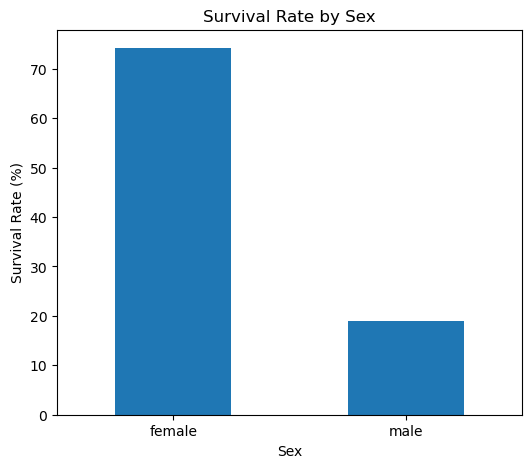

In [3]:
# 2. Survival Rate by Sex

survival_by_sex = data.groupby("Sex")["Survived"].mean() * 100

print("\nSurvival Rate by Sex:")
print(survival_by_sex)

plt.figure(figsize=(6, 5))
survival_by_sex.plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Sex")
plt.xticks(rotation=0)
plt.show()


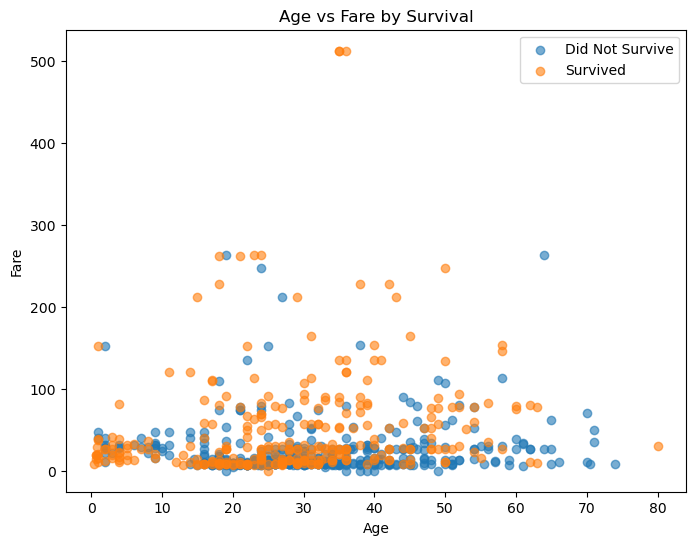

In [4]:
# 3. Age vs Fare by Survival

plt.figure(figsize=(8, 6))

survived_0 = data[data["Survived"] == 0]
survived_1 = data[data["Survived"] == 1]

plt.scatter(
    survived_0["Age"],
    survived_0["Fare"],
    label="Did Not Survive",
    alpha=0.6
)

plt.scatter(
    survived_1["Age"],
    survived_1["Fare"],
    label="Survived",
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare by Survival")
plt.legend()
plt.show()

### Observations
1) Females had a much higher survival rate than males, about 74% compared to 19%.
2) Survival was higher in better passenger classes, with first-class passengers having the best survival rate.
3) Pclass and Fare had a strong negative correlation because a higher Pclass number represents a lower class and generally lower fare.
4) Higher fares were generally associated with better survival chances.
5) Age and Fare did not show a strong relationship in the scatter plot.
6) The heatmap shows that most numerical variables have only weak to moderate correlations with each other.
7) Overall, gender, passenger class, and fare appear to be more strongly related to survival than age.